# 01 · Preprocessing
**Input :** `data/raw/HCC1/` and `data/raw/HCC2/` (MTX triplets)  
**Output:** `data/processed/adata_processed.h5ad`

Covers: data loading, QC metrics, cell filtering, normalisation, log-transform,
and highly variable gene selection.

**Run order:** **01** → 02 → 03 → 04 → 05


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))

from paths import REPO_ROOT, RAW_DIR, PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Raw data  : {RAW_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Raw data  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\raw


In [2]:
import scanpy as sc
from utils import (load_samples, qc_metrics, filter_cells,
                              normalize, select_hvg, save_adata)
print(f"Scanpy: {sc.__version__}")

Scanpy: 1.11.5


In [4]:
# ── Configuration ─────────────────────────────────────────────────────────────
MIN_GENES   = 200
MAX_GENES   = 2500
MAX_MT_PCT  = 5       # % mitochondrial reads
N_TOP_GENES = 2000    # highly variable genes to select

## 1 · Load data

In [5]:
adata = load_samples(RAW_DIR)
adata

Loaded: 25189 cells × 33694 genes
sample
normal (HCC1)    16077
tumor (HCC2)      9112


AnnData object with n_obs × n_vars = 25189 × 33694
    obs: 'sample'
    var: 'gene_ids', 'feature_types'

## 2 · QC metrics

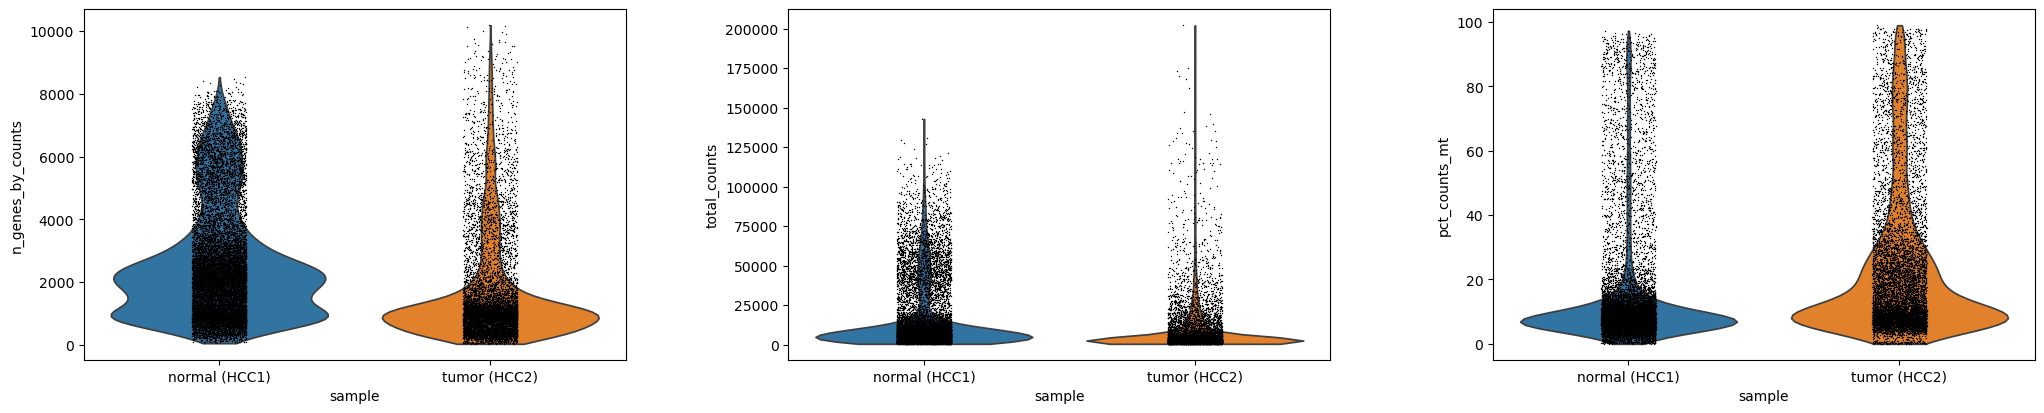

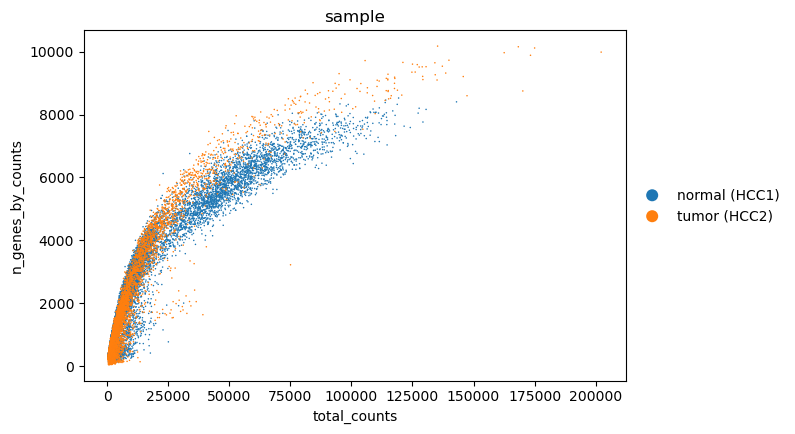

In [6]:
adata = qc_metrics(adata)
sc.pl.violin(adata, ["n_genes_by_counts","total_counts","pct_counts_mt"],
             groupby="sample", multi_panel=True)
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="sample")

## 3 · Filter cells

In [7]:
adata = filter_cells(adata, MIN_GENES, MAX_GENES, MAX_MT_PCT)

Before filtering : 25189 cells
After min_genes  : 24832 cells
After max_genes  : 16981 cells
After MT filter  : 2795 cells


## 4 · Normalise & log-transform

In [8]:
adata = normalize(adata)

Max expression after log1p: 8.88


## 5 · Highly variable genes

In [9]:
adata = select_hvg(adata, n_top_genes=N_TOP_GENES, batch_key='sample')

HVGs selected: 2000


## 6 · Save

In [10]:
save_adata(adata, PROC_DIR / 'adata_processed.h5ad')

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\adata_processed.h5ad  (2795 cells × 33694 genes)
